In [4]:
from IPython.core.display import display, HTML
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
# Set the maximum width for output display
display(HTML("<style>.container { width:50% !important; }</style>"))


C:\Users\thist\AppData\Local\Temp\ipykernel_5972\3115466222.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [5]:
df = pd.read_csv(r"C:\Users\thist\OneDrive\Desktop\mbta.csv")

In [6]:
# Display dfset structure
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names and df types:")
print(df.dtypes)
print("\nFirst few rows of the dfset:")
print(df.head())

Number of rows: 856683
Number of columns: 13

Column names and df types:
service_date              object
gtfs_route_id             object
gtfs_route_short_name     object
gtfs_route_long_name      object
gtfs_route_desc           object
route_category            object
mode_type                 object
peak_offpeak_ind          object
metric_type               object
otp_numerator            float64
otp_denominator          float64
cancelled_numerator      float64
ObjectId                   int64
dtype: object

First few rows of the dfset:
             service_date gtfs_route_id gtfs_route_short_name  \
0  2024/02/29 05:00:00+00           553                   553   
1  2024/02/29 05:00:00+00           554                   554   
2  2024/02/29 05:00:00+00           556                   556   
3  2024/02/29 05:00:00+00           558                   558   
4  2024/02/29 05:00:00+00            57                    57   

  gtfs_route_long_name                   gtfs_route_desc route_

In [7]:
# Count missing values in each column
missing_values_count = df.isnull().sum()

# Display count of missing values in each column
print("Count of missing values in each column:")
print(missing_values_count)

Count of missing values in each column:
service_date                  0
gtfs_route_id                 0
gtfs_route_short_name    114922
gtfs_route_long_name     698572
gtfs_route_desc               0
route_category            79290
mode_type                     0
peak_offpeak_ind              0
metric_type                   0
otp_numerator                 2
otp_denominator               2
cancelled_numerator       64203
ObjectId                      0
dtype: int64


In [8]:
# Creating new feature 'otp_rate'
df['otp_rate'] = df['otp_numerator'] / df['otp_denominator']
# Extract day of week
df['service_day'] = pd.to_datetime(df['service_date']).dt.day_name()
# Encode peak/offpeak
df['peak_encoded'] = df['peak_offpeak_ind'].apply(lambda x: 1 if x == 'PEAK' else 0)


In [9]:
# Code to handle missing values by imputation for a numerical column
df['otp_rate'] = df['otp_rate'].fillna(df['otp_rate'].mean())


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

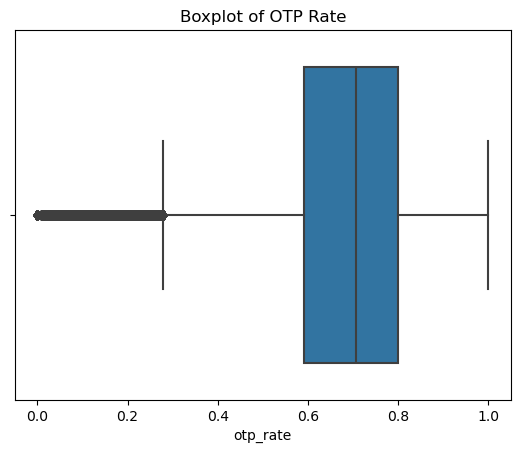

In [11]:
# Code to plot a boxplot for outliers in otp_rate
sns.boxplot(x=df['otp_rate'])
plt.title('Boxplot of OTP Rate')
plt.show()

C:\Users\thist\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


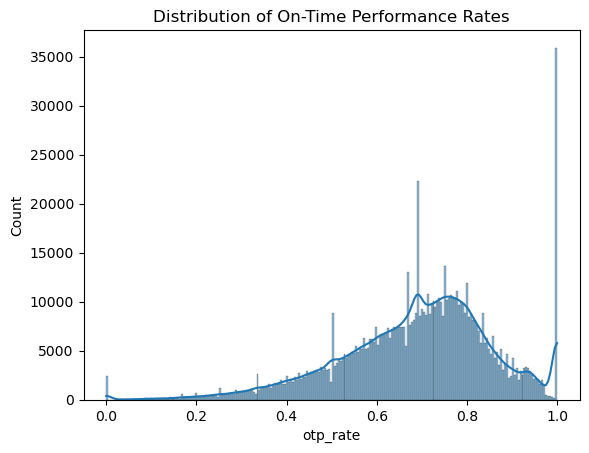

In [12]:


# Plotting the distribution of on-time performance rates
sns.histplot(df['otp_rate'].dropna(), kde=True)
plt.title('Distribution of On-Time Performance Rates')
plt.show()


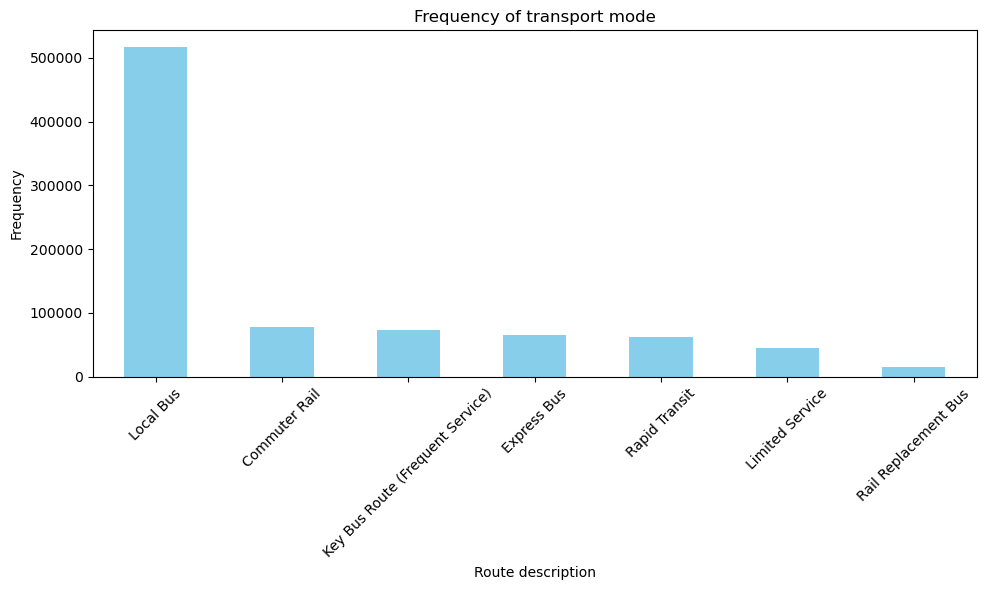

In [13]:
from pickle import FALSE

# Count the frequencies of gtf_route_desc
route_counts = df['gtfs_route_desc'].value_counts()

# Plotting bar chart to show transportation mode frequency
plt.figure(figsize=(10, 6))
route_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of transport mode')
plt.xlabel('Route description')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

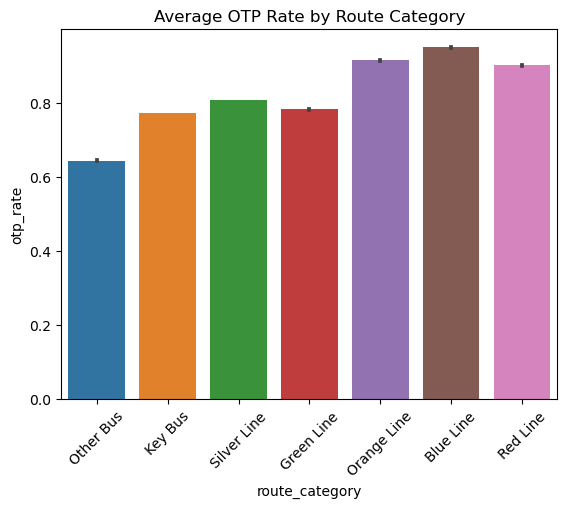

In [14]:
# Visualization of OTP rate by route category
sns.barplot(x='route_category', y='otp_rate', data=df)
plt.title('Average OTP Rate by Route Category')
plt.xticks(rotation=45)
plt.show()


In [15]:
# Feature Engineering

#Service Date
df['date'] = pd.to_datetime(df['service_date'])
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['time'] = df['date'].dt.time
df['day_of_week'] = df['date'].dt.dayofweek


In [16]:
 # Feature Engineering
 ## Categorize OTP rates directly without using a function
#df['OTP Category'] = pd.cut(df['OTP Rate'], bins=[-float('inf'), 0.3, 0.7, float('inf')], labels=['Low', 'Medium', 'High'])


In [17]:
# Feature Engineering
threshold = df['otp_rate'].median()

df['otp_label'] = pd.cut(df['otp_rate'], bins=[-float('inf'), threshold, float('inf')], labels=['low', 'high'])

In [18]:
df.head()

,service_date,gtfs_route_id,gtfs_route_short_name,gtfs_route_long_name,gtfs_route_desc,route_category,mode_type,peak_offpeak_ind,metric_type,otp_numerator,...,ObjectId,otp_rate,service_day,peak_encoded,date,month,day,time,day_of_week,otp_label
0,2024/02/29 05:00:00+00,553,553,NaN,Express Bus,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,43.0,...,1,0.467391,Thursday,0,2024-02-29 05:00:00+00:00,2,29,05:00:00,3,low
1,2024/02/29 05:00:00+00,554,554,NaN,Express Bus,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,20.0,...,2,0.800000,Thursday,0,2024-02-29 05:00:00+00:00,2,29,05:00:00,3,high
2,2024/02/29 05:00:00+00,556,556,NaN,Express Bus,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,10.0,...,3,0.526316,Thursday,0,2024-02-29 05:00:00+00:00,2,29,05:00:00,3,low
3,2024/02/29 05:00:00+00,558,558,NaN,Express Bus,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,14.0,...,4,0.636364,Thursday,0,2024-02-29 05:00:00+00:00,2,29,05:00:00,3,low
4,2024/02/29 05:00:00+00,57,57,NaN,Key Bus Route (Frequent Service),Key Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,807.0,...,5,0.734973,Thursday,0,2024-02-29 05:00:00+00:00,2,29,05:00:00,3,high


In [19]:
# checking distinct value count for all categorical variables
df.select_dtypes(include = ['object']).nunique()

service_date             2982
gtfs_route_id             204
gtfs_route_short_name     184
gtfs_route_long_name       28
gtfs_route_desc             7
route_category              7
mode_type                   3
peak_offpeak_ind            2
metric_type                 2
service_day                 7
time                        2
dtype: int64

In [20]:
# droping  the variables that have more than 7 unique values to avoid overfitting
df.drop(['service_date', 'gtfs_route_id', 'gtfs_route_short_name',
           'gtfs_route_long_name','gtfs_route_desc'], axis = 1, inplace = True)

In [21]:
df.apply(lambda x:x.unique())

route_category         [Other Bus, Key Bus, Silver Line, nan, Green L...
mode_type                                     [Bus, Commuter Rail, Rail]
peak_offpeak_ind                                        [OFF_PEAK, PEAK]
metric_type            [Headway / Schedule Adherence, Passenger Wait ...
otp_numerator          [43.0, 20.0, 10.0, 14.0, 807.0, 915.0, 501.0, ...
otp_denominator        [92.0, 25.0, 19.0, 22.0, 1098.0, 1256.0, 612.0...
cancelled_numerator    [nan, 0.0, 1.0, 3.0, 2.0, 12.0, 4.0, 6.0, 8.0,...
ObjectId               [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
otp_rate               [0.4673913043478261, 0.8, 0.5263157894736842, ...
service_day            [Thursday, Wednesday, Tuesday, Monday, Sunday,...
peak_encoded                                                      [0, 1]
date                   [2024-02-29 05:00:00+00:00, 2024-02-28 05:00:0...
month                            [2, 1, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3]
day                    [29, 28, 27, 26, 25, 24, 23,

In [22]:
# seperating the dependent variable y from independent variables x
x = df.drop('otp_label', axis = 1).copy()
y = df['otp_label'].copy()

In [23]:
# one-hot encoding to convert the categorical variables to continuous variables
x_enc = pd.get_dummies(df[['time', 'metric_type', 'mode_type', 'peak_offpeak_ind', 'route_category', 'day_of_week']]).astype(int)
display(x_enc.head())
display(x.shape)
display(x_enc.shape)

,day_of_week,time_04:00:00,time_05:00:00,metric_type_Headway / Schedule Adherence,metric_type_Passenger Wait Time,mode_type_Bus,mode_type_Commuter Rail,mode_type_Rail,peak_offpeak_ind_OFF_PEAK,peak_offpeak_ind_PEAK,route_category_Blue Line,route_category_Green Line,route_category_Key Bus,route_category_Orange Line,route_category_Other Bus,route_category_Red Line,route_category_Silver Line
0,3,0,1,1,0,1,0,0,1,0,0,0,0,0,1,0,0
1,3,0,1,1,0,1,0,0,1,0,0,0,0,0,1,0,0
2,3,0,1,1,0,1,0,0,1,0,0,0,0,0,1,0,0
3,3,0,1,1,0,1,0,0,1,0,0,0,0,0,1,0,0
4,3,0,1,1,0,1,0,0,1,0,0,0,1,0,0,0,0


(856683, 16)

(856683, 17)

In [24]:
# converting the dependent variable from categorical to continuous
display(y.value_counts())
y = y.apply(lambda x:1 if x =='high' else 0)
display(y.value_counts())

otp_label
low     428361
high    428322
Name: count, dtype: int64

otp_label
0    428361
1    428322
Name: count, dtype: int64

In [25]:
# checking the data stratification
sum(y)/len(y)
#The value is very close to 50%, suggesting that the dataset is
# roughly balanced between high and low instances.

0.4999772377880733

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [27]:
# splitting the data
x_train, x_test, y_train, y_test, = train_test_split(x_enc, y, random_state = 50, stratify = y )
print('train ratio =', sum(y_train)/ len(y_train))
print('test ratio =', sum(y_test)/ len(y_test))
x

train ratio = 0.49997665413252984
test ratio = 0.49997898875197855


,route_category,mode_type,peak_offpeak_ind,metric_type,otp_numerator,otp_denominator,cancelled_numerator,ObjectId,otp_rate,service_day,peak_encoded,date,month,day,time,day_of_week
0,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,43.0,92.0,NaN,1,0.467391,Thursday,0,2024-02-29 05:00:00+00:00,2,29,05:00:00,3
1,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,20.0,25.0,NaN,2,0.800000,Thursday,0,2024-02-29 05:00:00+00:00,2,29,05:00:00,3
2,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,10.0,19.0,NaN,3,0.526316,Thursday,0,2024-02-29 05:00:00+00:00,2,29,05:00:00,3
3,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,14.0,22.0,NaN,4,0.636364,Thursday,0,2024-02-29 05:00:00+00:00,2,29,05:00:00,3
4,Key Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,807.0,1098.0,NaN,5,0.734973,Thursday,0,2024-02-29 05:00:00+00:00,2,29,05:00:00,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856678,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,63.0,78.0,0.0,856679,0.807692,Saturday,0,2016-01-02 05:00:00+00:00,1,2,05:00:00,5
856679,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,3.0,10.0,0.0,856680,0.300000,Saturday,0,2016-01-02 05:00:00+00:00,1,2,05:00:00,5
856680,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,331.0,375.0,0.0,856681,0.882667,Saturday,0,2016-01-02 05:00:00+00:00,1,2,05:00:00,5
856681,Other Bus,Bus,OFF_PEAK,Headway / Schedule Adherence,338.0,445.0,0.0,856682,0.759551,Saturday,0,2016-01-02 05:00:00+00:00,1,2,05:00:00,5


In [28]:
# Split the data into training and temporary data (80% training, 20% temporary)
x_train, x_temp, y_train, y_temp = train_test_split(x_enc, y, test_size=0.2, random_state=50, stratify=y)

# Split the temporary data into validation and test sets (50% validation, 50% test)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=50, stratify=y_temp)

print('train ratio =', sum(y_train)/ len(y_train))
print('validation ratio =', sum(y_val)/ len(y_val))
print('test ratio =', sum(y_test)/ len(y_test))

train ratio = 0.4999766541279879
validation ratio = 0.49997665405985897
test ratio = 0.4999824907492792


In [29]:
import numpy as np

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

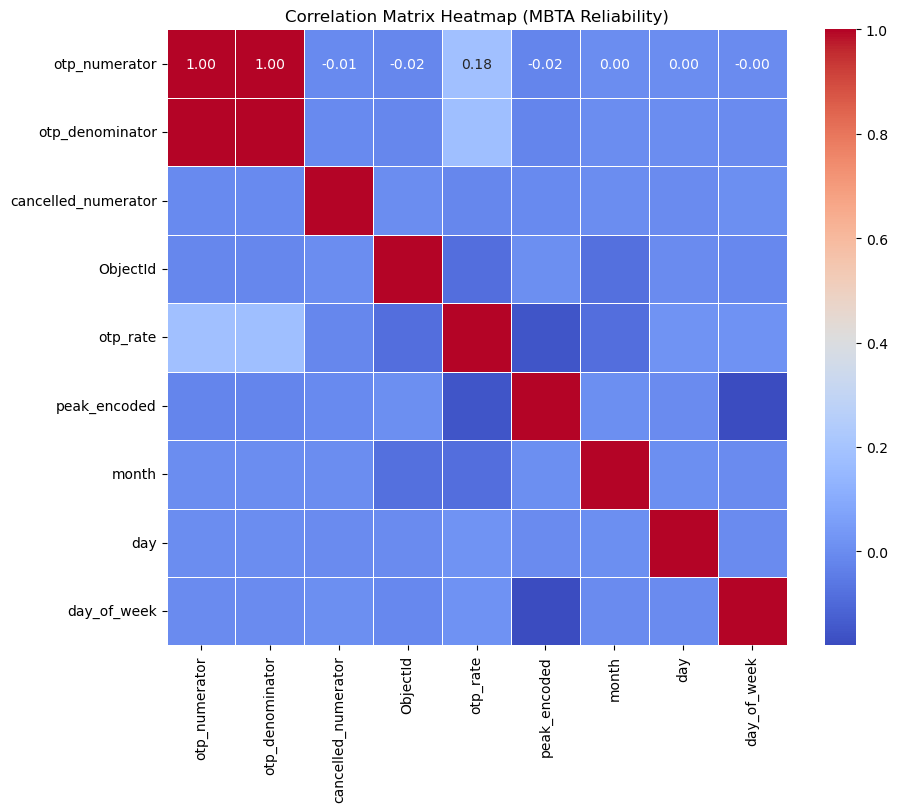

In [31]:
# Plot the heatmap
# Exclude non-numeric columns
numeric_columns = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_columns.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap (MBTA Reliability)')
plt.show()

In [32]:
# Fit the model to the training data (this is before parameter tuning)
logreg = LogisticRegression()
logreg.fit(x_train, y_train)

LogisticRegression()

In [33]:
# Initial Model Evaluation
y_val_pred_initial = logreg.predict(x_val)
accuracy_initial = accuracy_score(y_val, y_val_pred_initial)

print("Initial Model Accuracy:", accuracy_initial)


Initial Model Accuracy: 0.6884951206985105


In [34]:
# Get the coefficients of the trained model
coefficients = logreg.coef_[0]

# Get the names of the features
feature_names = x_train.columns

# Map coefficients to feature names
feature_coefficients = dict(zip(feature_names, coefficients))

# Sort coefficients by absolute value to see the most influential features
sorted_feature_coefficients = sorted(feature_coefficients.items(), key=lambda x: abs(x[1]), reverse=True)

print("Features used in the model:")
for feature, coefficient in sorted_feature_coefficients:
    print(f"{feature}: {coefficient}")


Features used in the model:
route_category_Blue Line: 2.089671829117598
route_category_Other Bus: -2.0428975948083736
route_category_Green Line: -1.763477924080207
route_category_Silver Line: 1.2716439364756922
metric_type_Passenger Wait Time: 1.152682695811581
mode_type_Rail: 1.152682695811581
peak_offpeak_ind_OFF_PEAK: 0.879691485757981
route_category_Key Bus: 0.6703076406845484
time_05:00:00: 0.625166892357821
route_category_Orange Line: 0.4657961206001519
route_category_Red Line: 0.3606926701741594
time_04:00:00: 0.337432787418373
metric_type_Headway / Schedule Adherence: -0.19008301603614516
mode_type_Bus: -0.1009460176486092
mode_type_Commuter Rail: -0.08913699838713265
peak_offpeak_ind_PEAK: 0.08290819401751272
day_of_week: -0.07969293041515317


In [35]:
# Calculate log likelihood
log_likelihood = logreg.score(x_train, y_train)

# Calculate number of parameters (including intercept term)
k = x_train.shape[1] + 1

# Number of observations
n = x_train.shape[0]

# Calculate BIC
BIC = -2 * log_likelihood + k * np.log(n)

# Calculate AIC
AIC = -2 * log_likelihood + 2 * k

print("BIC:", BIC)
print("AIC:", AIC)

BIC: 240.50575790720507
AIC: 34.62753412145106


In [36]:
 # Select features based on L1 regularization
feature_selector = SelectFromModel(LogisticRegression(penalty='l1', solver='saga'))
x_train_selected = feature_selector.fit_transform(x_train, y_train)
x_test_selected = feature_selector.transform(x_test)


In [37]:
# Hyperparameter Tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
grid_search = GridSearchCV(LogisticRegression(solver='saga'), param_grid, cv=5)
grid_search.fit(x_train_selected, y_train)
best_params = grid_search.best_params_


In [38]:
# Step 5: Optimized Model Training
final_logreg = LogisticRegression(solver='saga', **best_params)
final_logreg.fit(x_train_selected, y_train)

LogisticRegression(C=0.001, penalty='l1', solver='saga')

In [39]:
# Final Model Evaluation
y_test_pred = final_logreg.predict(x_test_selected)
accuracy_final = accuracy_score(y_test, y_test_pred)
print("Final Model Accuracy:", accuracy_final)

Final Model Accuracy: 0.6861408444127981


In [40]:
# Calculate log likelihood
log_likelihood_final = final_logreg.score(x_train_selected, y_train)

# Calculate number of parameters (including intercept term)
num_params_final = x_train_selected.shape[1] + 1

# Number of observations
num_obs_final = x_train_selected.shape[0]

# Calculate BIC for the final model
BIC_final = -2 * log_likelihood_final + num_params_final * np.log(num_obs_final)

# Calculate AIC for the final model
AIC_final = -2 * log_likelihood_final + 2 * num_params_final

print("BIC for the final model:", BIC_final)
print("AIC for the final model:", AIC_final)

BIC for the final model: 159.87775144104475
AIC for the final model: 22.625602250542062


In [41]:
# Get the mask of selected features
selected_mask = feature_selector.get_support()

# Get the indices of selected features
selected_indices = np.where(selected_mask)[0]

# Get the names of selected features
selected_feature_names = x_train.columns[selected_indices]

print("Selected Features:")
print(selected_feature_names)

Selected Features:
Index(['day_of_week', 'time_05:00:00', 'metric_type_Passenger Wait Time',
       'mode_type_Commuter Rail', 'mode_type_Rail',
       'peak_offpeak_ind_OFF_PEAK', 'route_category_Blue Line',
       'route_category_Green Line', 'route_category_Orange Line',
       'route_category_Other Bus', 'route_category_Silver Line'],
      dtype='object')


In [42]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

In [43]:
# performance metrics
classification_report(y_test, y_test_pred)



'              precision    recall  f1-score   support\n\n           0       0.63      0.89      0.74     42836\n           1       0.81      0.49      0.61     42833\n\n    accuracy                           0.69     85669\n   macro avg       0.72      0.69      0.67     85669\nweighted avg       0.72      0.69      0.67     85669\n'

In [44]:
 #Build confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[37913  4923]
 [21965 20868]]


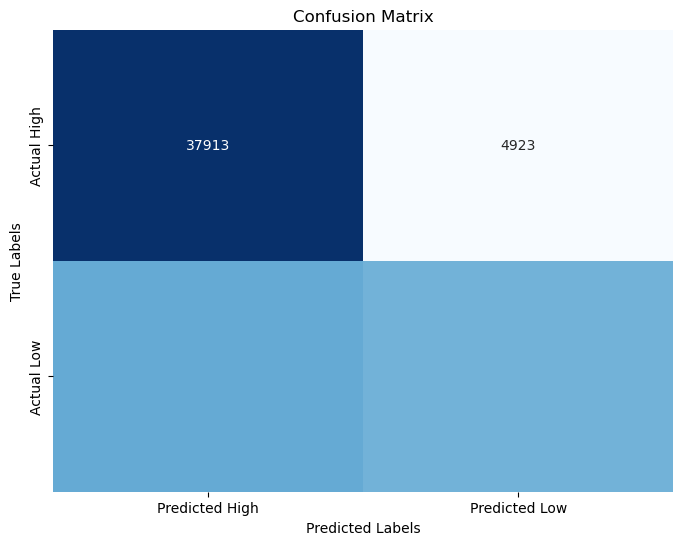

In [45]:

cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# Set labels
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.xticks([0.5, 1.5], ['Predicted High', 'Predicted Low'])
plt.yticks([0.5, 1.5], ['Actual High', 'Actual Low'])

plt.show()

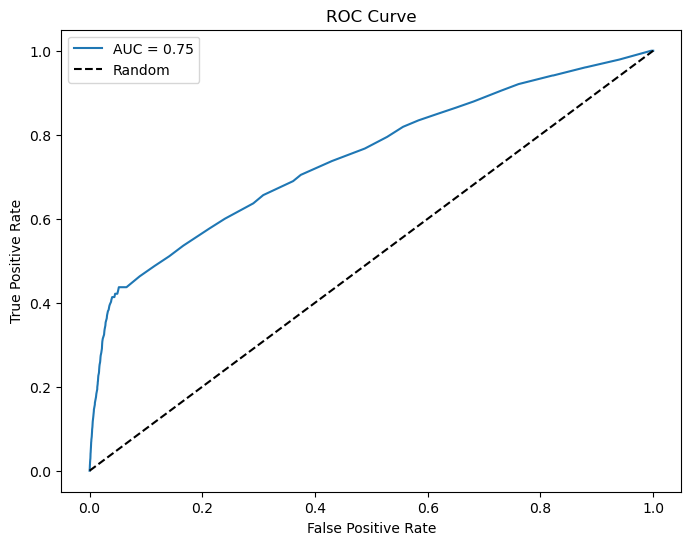

In [46]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, final_logreg.predict_proba(x_test_selected)[:, 1])

# Compute AUC score
auc = roc_auc_score(y_test, final_logreg.predict_proba(x_test_selected)[:, 1])

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the Random Forest model
rf = RandomForestClassifier(random_state=42)

# Define parameters for hyperparameter tuning
param_grid = {
    'n_estimators': [100],  # Number of trees in the forest
    'max_depth': [10, None],  # Maximum depth of the tree
    'min_samples_split': [2, 4],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]  # Minimum number of samples required to be at a leaf node
}


In [48]:
# Setup GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Best model after grid search
best_rf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [49]:
# Predictions on the test set
y_pred = best_rf.predict(x_test)
y_prob = best_rf.predict_proba(x_test)[:, 1]

Accuracy: 0.6993078009548378


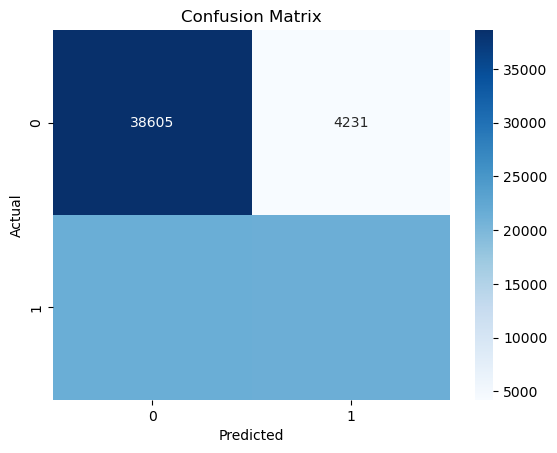

In [50]:
# Accuracy and Confusion Matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

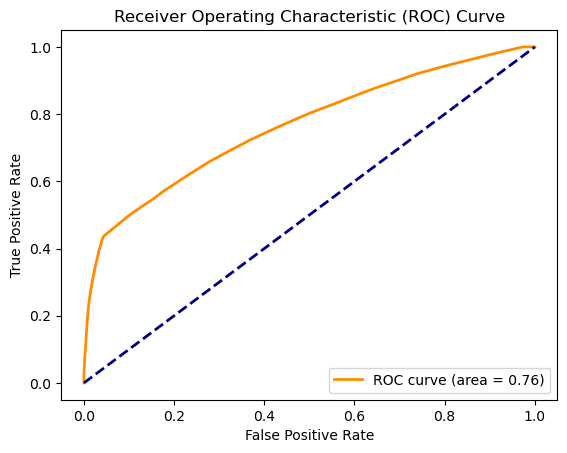

In [51]:
# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

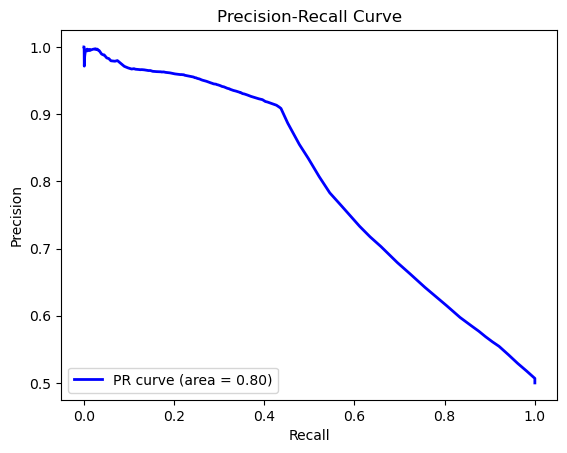

In [52]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

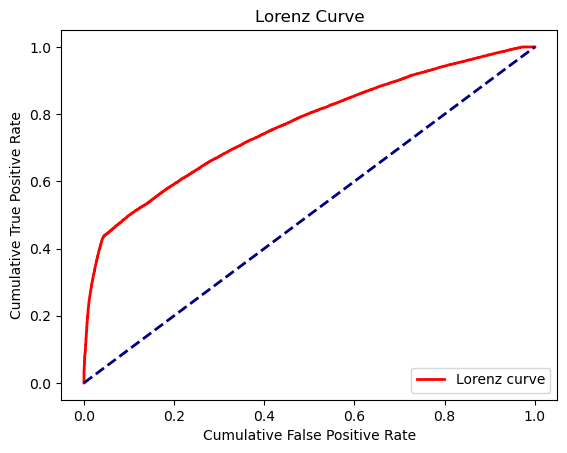

In [53]:
# Lorenz Curve
def lorenz_curve(y_true, y_score):
    pos = y_true[y_score.argsort()[::-1]]
    neg = 1 - pos
    cum_pos = np.cumsum(pos) / np.sum(pos)
    cum_neg = np.cumsum(neg) / np.sum(neg)
    return cum_neg, cum_pos

x_lorenz, y_lorenz = lorenz_curve(np.array(y_test), y_prob)
plt.figure()
plt.plot(x_lorenz, y_lorenz, color='red', lw=2, label='Lorenz curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Cumulative False Positive Rate')
plt.ylabel('Cumulative True Positive Rate')
plt.title('Lorenz Curve')
plt.legend(loc="lower right")
plt.show()